# Day 24 — Evaluation Metrics Exercises

**🎯 Objective:** Understand classification and regression metrics, demonstrate the failure of simple accuracy under high class imbalance, and analyze error behavior on outlier-laden regression data.

## Classification Metrics

In this section, we generate a synthetic imbalanced binary classification dataset (5% minority class, 95% majority class) and compare standard metrics:
- **Accuracy:** The proportion of correct predictions.
- **Precision:** The proportion of positive identifications that were actually correct.
- **Recall (Sensitivity):** The proportion of actual positives that were correctly identified.
- **F1-Score:** The harmonic mean of Precision and Recall.
- **ROC-AUC vs. PR-AUC:** The area under the ROC and Precision-Recall curves.

--- Metric Comparison Table ---
   Metric  Logistic Regression  Dummy Classifier (All 0s)
 Accuracy             0.949000                      0.933
Precision             0.863636                      0.000
   Recall             0.283582                      0.000
 F1-Score             0.426966                      0.000
  ROC-AUC             0.919358                      0.500


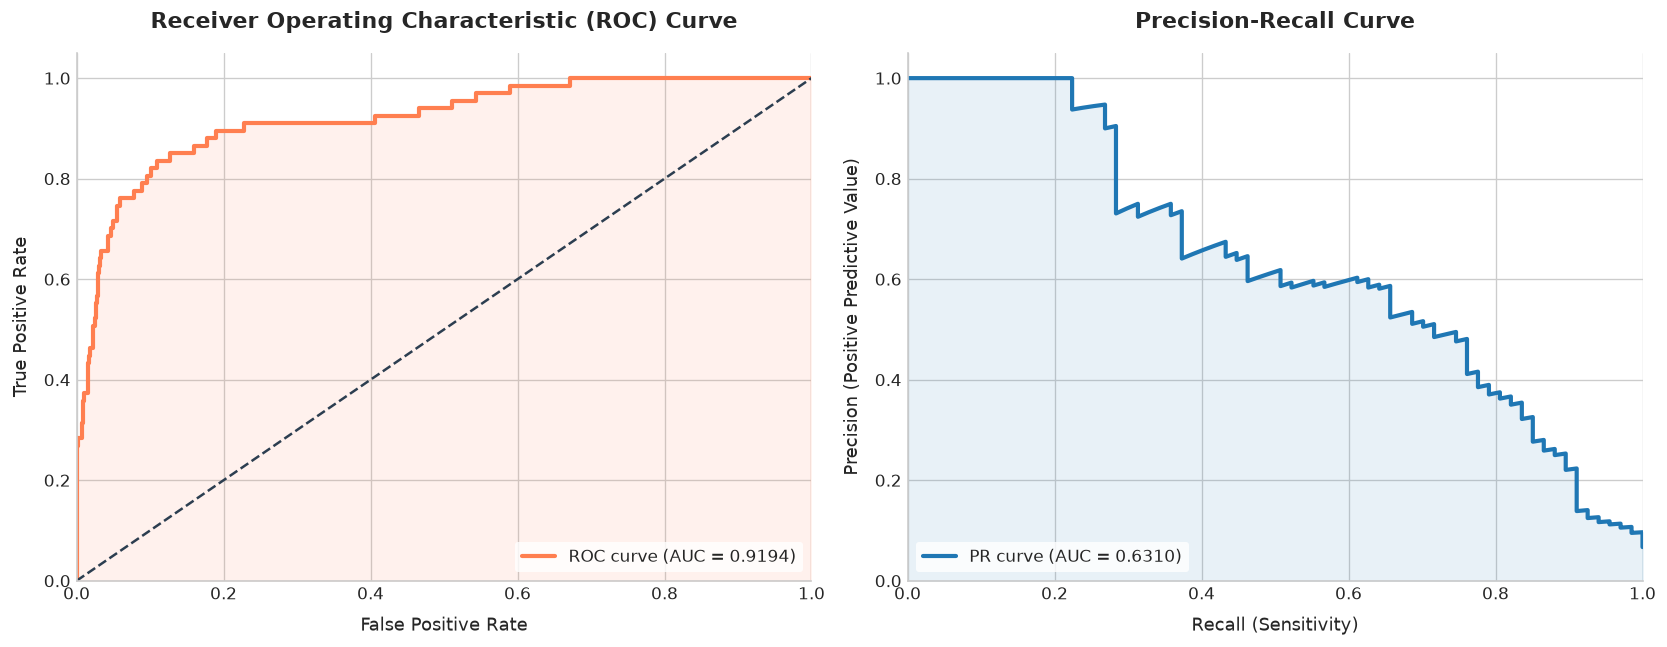

In [2]:
# Day 24 — exercises: Classification Metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc
)

# Set styling for matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Generate imbalanced classification dataset (5% class 1, 95% class 0)
X_cls, y_cls = make_classification(
    n_samples=5000, n_features=10, weights=[0.95, 0.05], random_state=42
)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

# Train a Logistic Regression model
cls_model = LogisticRegression(random_state=42)
cls_model.fit(X_train_cls, y_train_cls)

y_pred_prob = cls_model.predict_proba(X_test_cls)[:, 1]
y_pred = cls_model.predict(X_test_cls)

# Calculate metrics for Model
acc = accuracy_score(y_test_cls, y_pred)
prec = precision_score(y_test_cls, y_pred)
rec = recall_score(y_test_cls, y_pred)
f1 = f1_score(y_test_cls, y_pred)
roc_auc = roc_auc_score(y_test_cls, y_pred_prob)

# Generate dummy predictions (always predict majority class 0)
dummy_pred = np.zeros_like(y_test_cls)
dummy_acc = accuracy_score(y_test_cls, dummy_pred)
dummy_prec = precision_score(y_test_cls, dummy_pred, zero_division=0)
dummy_rec = recall_score(y_test_cls, dummy_pred, zero_division=0)
dummy_f1 = f1_score(y_test_cls, dummy_pred, zero_division=0)

# Create a comparison table
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [acc, prec, rec, f1, roc_auc],
    'Dummy Classifier (All 0s)': [dummy_acc, dummy_prec, dummy_rec, dummy_f1, 0.5]
})

print("--- Metric Comparison Table ---")
print(metrics_df.to_string(index=False))

# Plot ROC and PR curves
fpr, tpr, _ = roc_curve(y_test_cls, y_pred_prob)
precision, recall, _ = precision_recall_curve(y_test_cls, y_pred_prob)
pr_auc = auc(recall, precision)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot ROC Curve with gradient fill
ax1.plot(fpr, tpr, color='#ff7f50', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.fill_between(fpr, tpr, color='#ff7f50', alpha=0.1)
ax1.plot([0, 1], [0, 1], color='#2c3e50', lw=1.5, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=11, labelpad=8)
ax1.set_ylabel('True Positive Rate', fontsize=11, labelpad=8)
ax1.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc="lower right", frameon=True, facecolor='white', edgecolor='none')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot Precision-Recall Curve with gradient fill
ax2.plot(recall, precision, color='#1f77b4', lw=2.5, label=f'PR curve (AUC = {pr_auc:.4f})')
ax2.fill_between(recall, precision, color='#1f77b4', alpha=0.1)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Sensitivity)', fontsize=11, labelpad=8)
ax2.set_ylabel('Precision (Positive Predictive Value)', fontsize=11, labelpad=8)
ax2.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold', pad=15)
ax2.legend(loc="lower left", frameon=True, facecolor='white', edgecolor='none')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Regression Metrics

In this section, we generate a synthetic regression dataset and add **severe outliers** to demonstrate how different metrics penalize them:
- **Mean Absolute Error (MAE):** Average absolute difference. Robust to outliers.
- **Root Mean Squared Error (RMSE):** Square root of average squared difference. Sensitive to outliers.
- **R-squared (R2):** Coefficient of determination, indicating goodness of fit.

--- Regression Metrics with Outliers ---
MAE:  19.9786
RMSE: 41.5964 (Notice how RMSE is larger due to outlier penalization)
R2:   0.0860


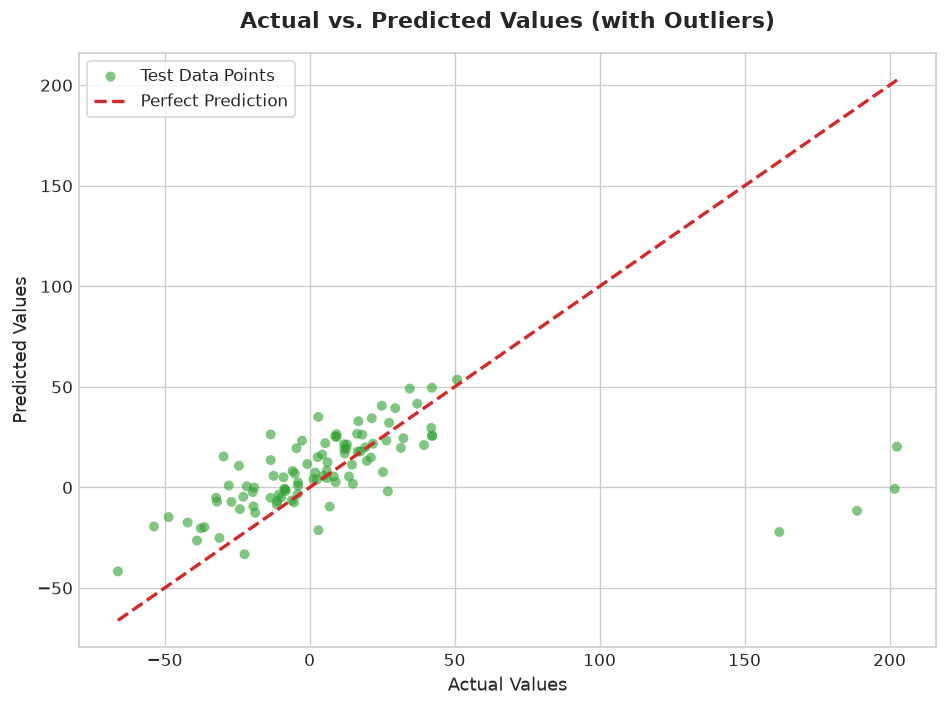

In [3]:
# Day 24 — exercises: Regression Metrics
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generate regression dataset
X_reg, y_reg = make_regression(
    n_samples=500, n_features=2, noise=15.0, random_state=42
)

# Introduce a small number of severe outliers in the target variable
y_reg_outliers = y_reg.copy()
y_reg_outliers[:15] += 200.0  # Significant shift

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg_outliers, test_size=0.2, random_state=42
)

# Train a Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg)

# Compute metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("--- Regression Metrics with Outliers ---")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f} (Notice how RMSE is larger due to outlier penalization)")
print(f"R2:   {r2:.4f}")

# Plot Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6, color='#2ca02c', edgecolors='none', label='Test Data Points')
# Plot diagonal line
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#d62728', linestyle='--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Values', fontsize=11)
plt.ylabel('Predicted Values', fontsize=11)
plt.title('Actual vs. Predicted Values (with Outliers)', fontsize=13, fontweight='bold', pad=15)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

## Reflection and Learnings

- **Key Learning:** Accuracy is not a reliable metric for imbalanced classification problems. A naive classifier can achieve high accuracy by simply predicting the majority class.
- **Imbalanced Data Choice:** PR-AUC is far more informative than ROC-AUC when evaluating highly imbalanced classes because it does not include True Negatives in its calculation.
- **Error Penalization:** RMSE is crucial when large errors are unacceptable, while MAE is preferred when outliers should not distort the average error representation.